# ShellSIM Gridded Pipeline: From Single-Point to Full Grid

## What is this notebook?

This notebook is the **production-scale** version of the ShellSIM oyster growth model.
The model (`ShellSIM_test_script_timeseries.ipynb`) originally ran on a *single location's*
time series of ocean conditions.  Here we lift that exact same physics and wrap it so it runs
over an **entire grid of ocean pixels** — thousands of lat/lon points — in parallel.

**The end result:** a 3-D NetCDF file (`latitude × longitude × time`) containing oyster
growth predictions for every ocean pixel in your study area.

---

## Big-picture workflow

```
  [Raw NetCDF inputs]          [ShellSIM FABM Model]        [Gridded Output]
  ┌──────────────────┐         ┌──────────────────┐         ┌────────────────────────┐
  │ Temperature (T)  │         │  run_fabm_at_    │         │ soft_tissue_energy [J] │
  │ Salinity    (S)  │──────►  │  point_full()    │──────►  │ shell_energy       [J] │
  │ Chlorophyll (Chl)│  per    │                  │  for    │ TFW (fresh weight) [g] │
  │ POC              │  pixel  │  (same loop as   │  every  │ SL  (shell length) [cm]│
  │ POM              │         │   notebook 1)    │  pixel  │ aging, C1/C2/C3 ...    │
  │ TPM              │         └──────────────────┘         └────────────────────────┘
  └──────────────────┘
        ▼
  Aligned to same
  daily time grid,
  same lat/lon grid
        ▼
  Two parallel strategies:
    Method 1 – Dask apply_ufunc (fire-and-forget, fastest overall)
    Method 2 – Batched chunks   (safe for RAM-limited environments)
```

---

## Input variables required

| Variable | Description | Typical source |
|---|---|---|
| `T_timeseries` | Sea surface temperature | CMEMS physics reanalysis |
| `S_timeseries` | Practical salinity | CMEMS physics reanalysis |
| `Chl_timeseries` | Chlorophyll-a concentration | CMEMS bio / satellite |
| `POC_timeseries` | Particulate Organic Carbon | CMEMS MULTIOBS BGC |
| `POM_timeseries` | Particulate Organic Matter | Derived / CMEMS |
| `TPM_timeseries` | Total Particulate Matter | Derived / CMEMS |

All variables are 3-D (time × latitude × longitude) NetCDF files.  They can arrive at
different temporal resolutions (daily, weekly, monthly) — the pipeline interpolates
everything to a common daily time axis before the model runs.


## Step 1 — Imports

Load every Python library the notebook needs.  Run this cell first every session.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Imports
# PURPOSE: Load all libraries needed throughout this notebook.
#
# Key libraries and why we need them:
#   xarray    – the main tool for reading and manipulating NetCDF (gridded ocean data)
#   pandas    – date/time handling and simple tabular data work
#   numpy     – fast array maths (the model runs on numpy arrays under the hood)
#   pyfabm    – the ShellSIM biophysical model engine (FABM = Framework for Aquatic Biogeochemical Models)
#   dask      – splits huge arrays into chunks and runs them in parallel across CPU cores
#   matplotlib – plotting
#   gc        – garbage collector, lets us free memory explicitly after heavy computations
#   warnings  – suppress noisy but harmless library warnings
# ─────────────────────────────────────────────────────────────────────────────
import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
import gc
import datetime
import warnings
from contextlib import redirect_stdout
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')  # suppress verbose library warnings
print('All libraries loaded successfully.')


All libraries loaded successfully.


## Step 2 — Define Integration Period

Set the **start** and **end** dates for the simulation.  The model will step forward
one day at a time between these dates.  The longer the period the more memory and
compute time required — start with a short window to test, then widen it.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Define the simulation time window
#
# HOW TO CHANGE:
#   Edit `start` and `end` to match the date range of your input data.
#   Format: 'DD-MM-YYYY'
#
# WHAT IT PRODUCES:
#   time_horizon – a pandas DatetimeIndex of daily timestamps.
#   time_horizon_len – integer count of days (used to size output arrays).
#
# TIP: For a quick test run, use a short window (e.g. 2-3 days).
#      For a full seasonal run, use 3-12 months — but expect longer compute time.
# ─────────────────────────────────────────────────────────────────────────────

start = '01-06-2021'
end   = '12-06-2021'

time_horizon     = pd.date_range(start=start, end=end, freq='1d')
time_horizon_len = len(time_horizon)

print(f'Simulation period : {start}  →  {end}')
print(f'Total days        : {time_horizon_len}')


Simulation period : 01-06-2021  →  12-06-2021
Total days        : 335


## Step 3 — Data Loading Helper

The `load_nc_file` function does several things in one call:
1. Opens a real NetCDF file from disk (if it exists).
2. If the file is missing it creates a **fake** (random) dataset with matching
   dimensions — so the rest of the notebook still runs and you can test the pipeline.
3. Reports the geographic bounding box and approximate area of the dataset.

The chunking config tells Dask how to divide the data into tiles; this is important
for efficient parallel execution later.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Chunking configuration and data-loading helper function
#
# CHUNKING explained for newcomers:
#   Imagine a 3-D block of data (time × lat × lon).
#   Dask slices this block into smaller sub-cubes called 'chunks'.
#   Each chunk is processed independently on a CPU core.
#   Good chunk sizes fill ~128 MB of RAM each.
#
#   time: -1   → keep ALL time steps together in each chunk
#               (the model needs the full time series at every pixel)
#   latitude: 80  → process 80 latitude rows at a time
#   longitude: 110 → process 110 longitude columns at a time
#
# EARTH_RADIUS_KM  – used only to print the approximate study-area size in km².
# _GLOBAL_COORDS   – a module-level cache so that fake datasets generated later
#                    use the same grid as the first real dataset loaded.
# ─────────────────────────────────────────────────────────────────────────────

chunking_config  = {'time': -1, 'latitude': 80, 'longitude': 110}
EARTH_RADIUS_KM  = 6371.0
_GLOBAL_COORDS   = None


def load_nc_file(file_path, var_name_in_file, chunking_config=chunking_config):
    """
    Load a NetCDF file into an xarray Dataset, backed by Dask lazy arrays.

    Parameters
    ----------
    file_path : str
        Path to the .nc file on disk.
    var_name_in_file : str
        Name of the primary variable inside the file (used when creating fake data).
    chunking_config : dict, optional
        Dask chunk sizes for each dimension.

    Returns
    -------
    xr.Dataset  – lazy-loaded (data not yet in RAM; Dask loads on demand).

    Side-effects
    ------------
    Populates _GLOBAL_COORDS from the first real dataset so subsequent fake
    datasets share the same lat/lon/time grid.
    """
    global _GLOBAL_COORDS
    fake_filename = f'{var_name_in_file}_gridded_FAKE.nc'

    # ── Branch A: real file found on disk ─────────────────────────────────────
    if os.path.exists(file_path):
        print(f'Successfully loaded: {var_name_in_file}')
        ds = xr.open_dataset(file_path, chunks=chunking_config)

        # Extract coordinate arrays, handling both 'latitude'/'lat' naming conventions
        try:
            lat_coords  = ds['latitude'].values  if 'latitude'  in ds.coords else ds['lat'].values
            lon_coords  = ds['longitude'].values if 'longitude' in ds.coords else ds['lon'].values
            time_coords = ds['time'].values      if 'time'      in ds.coords else None

            if _GLOBAL_COORDS is None:
                _GLOBAL_COORDS = {
                    'lat':      lat_coords,
                    'lon':      lon_coords,
                    'time':     time_coords,
                    'lat_name': 'latitude'  if 'latitude'  in ds.coords else 'lat',
                    'lon_name': 'longitude' if 'longitude' in ds.coords else 'lon'
                }
                print(f'✅ Set global coordinate reference from: {var_name_in_file}')
        except KeyError:
            print('❌ ERROR: Dataset is missing lat/lon coordinates.')
            return ds

        # ── Print geographic summary ──────────────────────────────────────────
        lat_min, lat_max = lat_coords.min(), lat_coords.max()
        lon_min, lon_max = lon_coords.min(), lon_coords.max()
        lat_range_deg    = lat_max - lat_min
        lon_range_deg    = lon_max - lon_min

        # Convert degree ranges to km (longitude distance shrinks toward the poles)
        lat_km = lat_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360)
        mid_lat_rad = np.deg2rad((lat_max + lat_min) / 2)
        lon_km = lon_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360) * np.cos(mid_lat_rad)
        approx_area_km2 = lat_km * lon_km

        print(f'🗺️  Geographic Coverage:')
        print(f'   BBOX (xMin, yMin, xMax, yMax): ({lon_min:.2f}, {lat_min:.2f}, {lon_max:.2f}, {lat_max:.2f})')
        print(f'   Lat range : {lat_min:.2f}° to {lat_max:.2f}°  ({lat_range_deg:.2f}°)')
        print(f'   Lon range : {lon_min:.2f}° to {lon_max:.2f}°  ({lon_range_deg:.2f}°)')
        print(f'   Approx. area : {approx_area_km2:,.0f} km²')
        print('─' * 50 + '\n')
        return ds

    # ── Branch B: cached fake file already on disk ────────────────────────────
    if os.path.exists(fake_filename):
        print(f'Using existing fake dataset: {fake_filename}\n')
        return xr.open_dataset(fake_filename, chunks=chunking_config)

    # ── Branch C: create a fresh fake dataset ─────────────────────────────────
    # This ensures the notebook still executes end-to-end even without real data.
    # The fake values are random [0,1] and have no physical meaning, but the
    # grid shape, coordinate names, and chunk layout will match real data.
    if _GLOBAL_COORDS is None:
        print('⚠️  WARNING: No real dataset loaded yet. Using default coordinates for fake data.')
        fake_lats    = np.linspace(40, 50, 100)
        fake_lons    = np.linspace(-10, 0, 100)
        time_horizon = np.arange(0, 30)
        lat_name, lon_name = 'latitude', 'longitude'
    else:
        print(f'📍 Creating fake data matching global coordinate reference')
        fake_lats    = _GLOBAL_COORDS['lat']
        fake_lons    = _GLOBAL_COORDS['lon']
        lat_name     = _GLOBAL_COORDS['lat_name']
        lon_name     = _GLOBAL_COORDS['lon_name']
        time_horizon = _GLOBAL_COORDS['time'] if _GLOBAL_COORDS.get('time') is not None else np.arange(0, 30)

    time_horizon_len_local = len(time_horizon)
    fake_data = np.random.rand(time_horizon_len_local, len(fake_lats), len(fake_lons))

    fake_ds = xr.Dataset(
        {var_name_in_file: (['time', lat_name, lon_name], fake_data)},
        coords={'time': time_horizon, lat_name: fake_lats, lon_name: fake_lons}
    )
    fake_ds.to_netcdf(fake_filename)
    print(f'✅ Saved fake dataset: {fake_filename}')
    print(f'   Dimensions: time[{time_horizon_len_local}] × {lat_name}[{len(fake_lats)}] × {lon_name}[{len(fake_lons)}]')
    return xr.open_dataset(fake_filename, chunks=chunking_config)


## Step 4 — Input File Paths

Update the file paths below to point to your actual NetCDF data.
If a path does not exist on disk, the loader will generate *fake* random data so the
rest of the pipeline still runs correctly — useful for testing the code logic.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: File paths for all six input variables
#
# HOW TO USE:
#   Replace each *_file_path string with the real path to your downloaded NetCDF file.
#   Keep the *_var_name strings matching the variable name INSIDE that NetCDF file
#   (you can check with `xr.open_dataset(path)` to see the variable names).
#
# DATA SOURCE NOTE:
#   POC and Salinity here come from CMEMS (Copernicus Marine Service).
#   Temperature, Chl, POM, TPM paths are set to non-existent files so fake data
#   is auto-generated for demonstration — replace with real paths before a full run.
# ─────────────────────────────────────────────────────────────────────────────

# ── POC : Particulate Organic Carbon (4-D: depth × time × lat × lon) ─────────
poc_file_path = (
    '/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/'
    'cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_'
    '13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc'
)
poc_var_name = 'poc'

# ── Salinity : Sea-surface salinity (4-D: depth × time × lat × lon) ──────────
salinity_file_path = (
    '/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/'
    'cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_'
    '13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc'
)
salinity_var_name = 'sos'

# ── The remaining four variables: set to fake paths for demo ─────────────────
# Replace with real NetCDF paths when real data is available.
temp_file_path = 'non_existent_temp.nc'  ;  temp_var_name = 'temperature'
chl_file_path  = 'non_existent_chl.nc'   ;  chl_var_name  = 'chl'
pom_file_path  = 'non_existent_pom.nc'   ;  pom_var_name  = 'pom'
tpm_file_path  = 'non_existent_tpm.nc'   ;  tpm_var_name  = 'tpm'

print('File paths configured.')


File paths configured.


## Step 5 — Load All Datasets

This single cell loads (or creates) all six input variables.
Note that Dask loads lazily — no actual data is read from disk yet,
only the file metadata.  The heavy reading happens during computation later.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Load all six input datasets
#
# Each call to load_nc_file:
#   1. Checks whether the file exists on disk.
#   2. If yes: opens it with Dask (lazy, memory-efficient).
#   3. If no:  generates a random fake dataset with matching coordinates.
#
# We load POC first so that _GLOBAL_COORDS is populated from a real dataset;
# all subsequent fake datasets will inherit its lat/lon/time grid.
# ─────────────────────────────────────────────────────────────────────────────

print('Loading datasets...\n')
# Tip: visualise the bounding box at http://bboxfinder.com/#30.06,-12.94,69.94,41.94
ds_poc  = load_nc_file(poc_file_path,      poc_var_name)
ds_sal  = load_nc_file(salinity_file_path, salinity_var_name)
ds_temp = load_nc_file(temp_file_path,     temp_var_name)
ds_chl  = load_nc_file(chl_file_path,      chl_var_name)
ds_pom  = load_nc_file(pom_file_path,      pom_var_name)
ds_tpm  = load_nc_file(tpm_file_path,      tpm_var_name)

print('\nAll datasets ready (lazily loaded — no data in RAM yet).')


Loading datasets...

Successfully loaded: poc


getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc: Operation not supported


✅ Set global coordinate reference from: poc
🗺️  Geographic Coverage:
   BBOX (xMin, yMin, xMax, yMax): (-12.88, 30.12, 41.88, 69.88)
   Lat range : 30.12° to 69.88°  (39.75°)
   Lon range : -12.88° to 41.88°  (54.75°)
   Approx. area : 17,296,519 km²
──────────────────────────────────────────────────

Successfully loaded: sos


getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc: Operation not supported


🗺️  Geographic Coverage:
   BBOX (xMin, yMin, xMax, yMax): (-12.94, 30.06, 41.94, 69.94)
   Lat range : 30.06° to 69.94°  (39.88°)
   Lon range : -12.94° to 41.94°  (54.88°)
   Approx. area : 17,390,524 km²
──────────────────────────────────────────────────

📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset: temperature_gridded_FAKE.nc
   Dimensions: time[5] × latitude[160] × longitude[220]
📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset: chl_gridded_FAKE.nc
   Dimensions: time[5] × latitude[160] × longitude[220]
📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset: pom_gridded_FAKE.nc
   Dimensions: time[5] × latitude[160] × longitude[220]
📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset: tpm_gridded_FAKE.nc
   Dimensions: time[5] × latitude[160] × longitude[220]

All datasets ready (lazily loaded — no data in RAM yet).


## Step 6 — Align All Variables to a Common Daily Grid

The six input variables may come from different providers at different:
- **Temporal resolutions** (daily, weekly, monthly)
- **Spatial grids** (slightly different lat/lon spacing)
- **Depth structures** (some have a depth dimension, some don't)

This cell standardises everything to a **single daily time axis** and the
**same lat/lon grid** (using the POC dataset as the reference grid).
Missing edge values are filled by extrapolation.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Coordinate alignment — bring all variables onto one common grid
#
# WHY THIS MATTERS:
#   The ShellSIM model needs all six variables at the SAME time steps and the
#   SAME lat/lon pixel locations.  If the grids don't match, you can't pass
#   matching arrays into the model.
#
# HOW IT WORKS:
#   xr.DataArray.interp() performs linear interpolation to map one grid onto
#   another.  fill_value='extrapolate' extends values beyond the original
#   time range rather than inserting NaNs.
#
# DEPTH VARIABLES (poc, sal):
#   These datasets have a depth dimension.  We select the surface layer
#   (depth index = 0) before interpolating.
#
# REFERENCE GRID: ds_poc (latitude, longitude)
#   All variables are interpolated onto POC's lat/lon grid.
# ─────────────────────────────────────────────────────────────────────────────

print('Aligning coordinates to common daily grid...')
ref_lats    = ds_poc.latitude
ref_lons    = ds_poc.longitude
interp_kwargs = {'fill_value': 'extrapolate'}

# 4-D variables: select surface layer (depth=0) first, then interpolate in time + space
poc_daily = (
    ds_poc[poc_var_name]
    .sel(depth=0, method='nearest')
    .interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
)
sal_daily = (
    ds_sal[salinity_var_name]
    .sel(depth=0, method='nearest')
    .interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
)

# 3-D variables: interpolate directly in time + space
temp_daily = ds_temp[temp_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
chl_daily  = ds_chl[chl_var_name ].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
pom_daily  = ds_pom[pom_var_name ].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
tpm_daily  = ds_tpm[tpm_var_name ].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)

# Merge all aligned variables into a single Dataset
# This makes downstream operations (subsetting, passing to the model) much cleaner.
ds_daily = xr.Dataset({
    'temperature': temp_daily,
    'salinity':    sal_daily,
    'Chl':         chl_daily,
    'POC':         poc_daily,
    'POM':         pom_daily,
    'TPM':         tpm_daily,
})

print('✅ Merged daily dataset ready.')
print('   Variables :', list(ds_daily.data_vars))
print('   Dimensions:', dict(ds_daily.dims))
ds_daily


Aligning coordinates to common daily grid...
✅ Merged daily dataset ready.
   Variables : ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
   Dimensions: {'time': 335, 'latitude': 160, 'longitude': 220}


<xarray.Dataset> Size: 519MB
Dimensions:      (time: 335, latitude: 160, longitude: 220)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-06 2021-01-07 ... 2021-12-06
  * latitude     (latitude) float32 640B 30.12 30.38 30.62 ... 69.38 69.62 69.88
  * longitude    (longitude) float32 880B -12.88 -12.62 -12.38 ... 41.62 41.88
    depth        float32 4B 0.0
Data variables:
    temperature  (time, latitude, longitude) float64 94MB dask.array<chunksize=(84, 80, 220), meta=np.ndarray>
    salinity     (time, latitude, longitude) float64 94MB dask.array<chunksize=(42, 40, 220), meta=np.ndarray>
    Chl          (time, latitude, longitude) float64 94MB dask.array<chunksize=(84, 80, 220), meta=np.ndarray>
    POC          (time, latitude, longitude) float32 47MB dask.array<chunksize=(84, 80, 220), meta=np.ndarray>
    POM          (time, latitude, longitude) float64 94MB dask.array<chunksize=(84, 80, 220), meta=np.ndarray>
    TPM          (time, latitude, longitude) float64 94MB dask.array<chunksize=(84, 80, 220), meta=np.ndarray>

## Step 7 — Quality-Check: Visualise Input Data

Before running the model it is good practice to **look at the input data**.
This cell plots:
1. **Spatial maps** — time-averaged maps of all six variables (what the ocean looks like).
2. **Time series** — temperature/salinity and food-proxy variables at a central pixel.

What to look for:
- Suspiciously uniform values (may indicate fake/constant data)
- Large areas of NaN (land, missing data)
- Implausible values (temperature > 40 °C, negative concentrations)


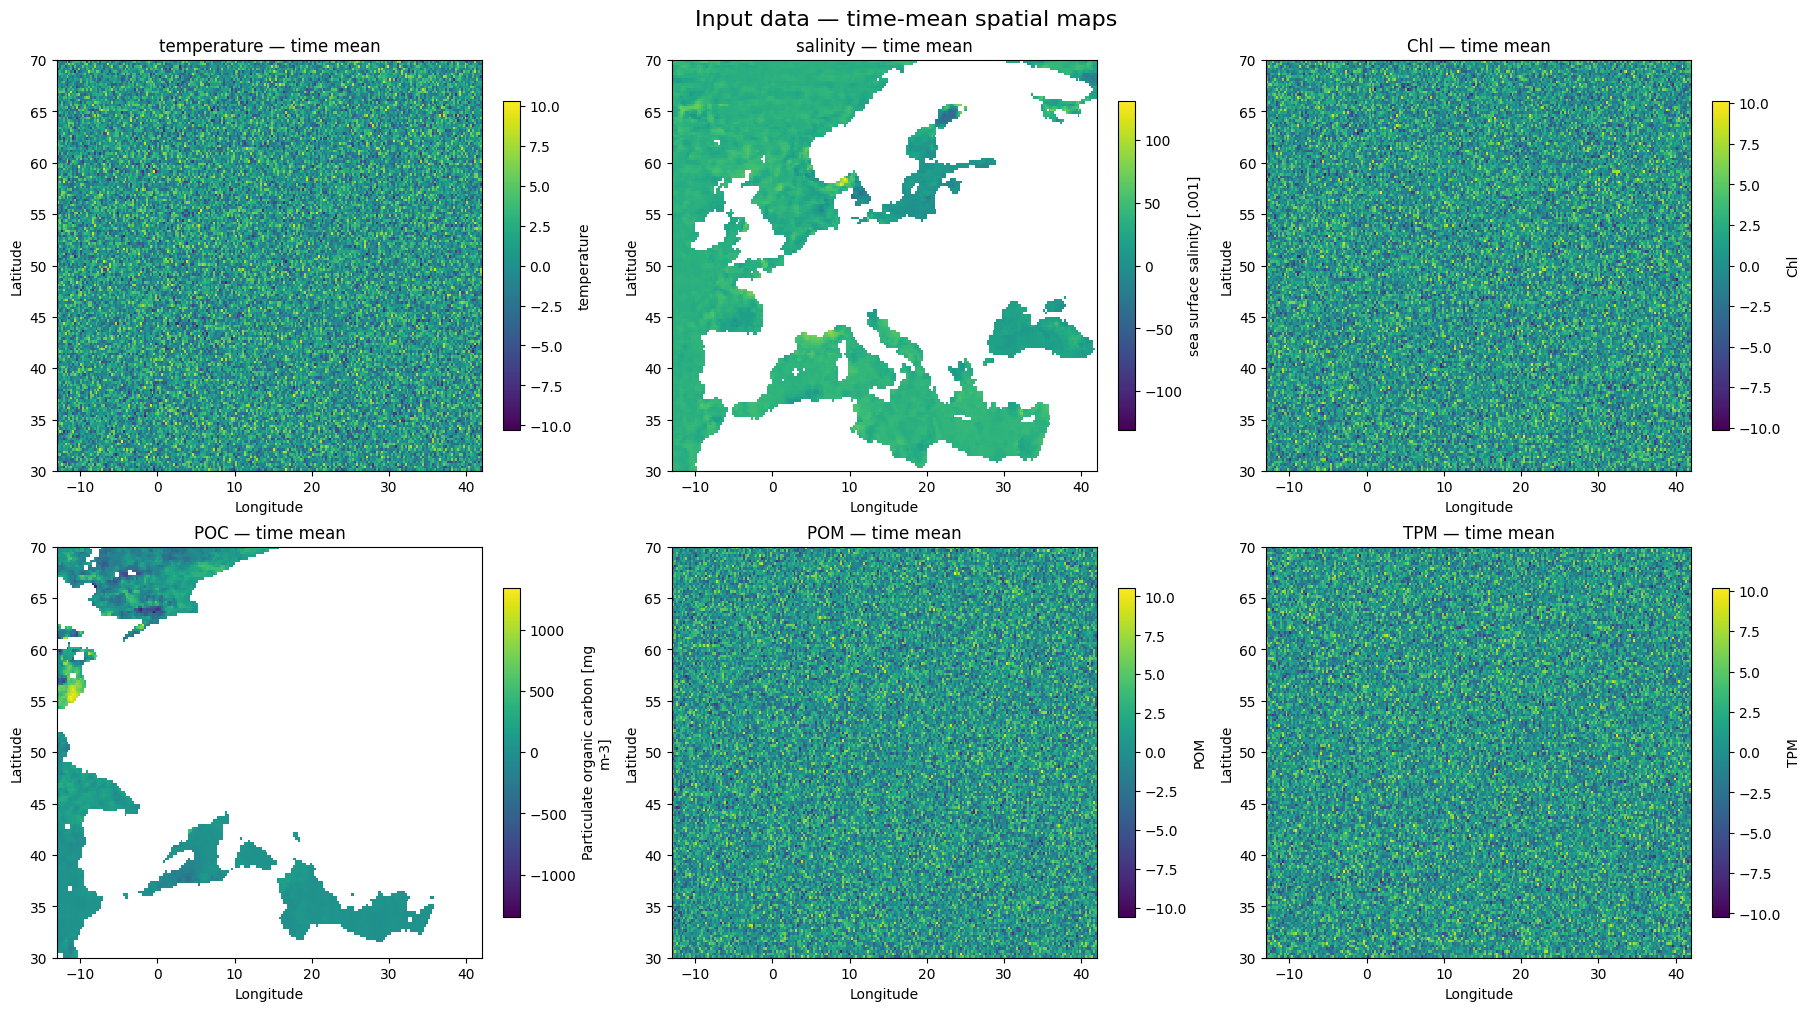

Saved: qc_input_time_mean_maps.png


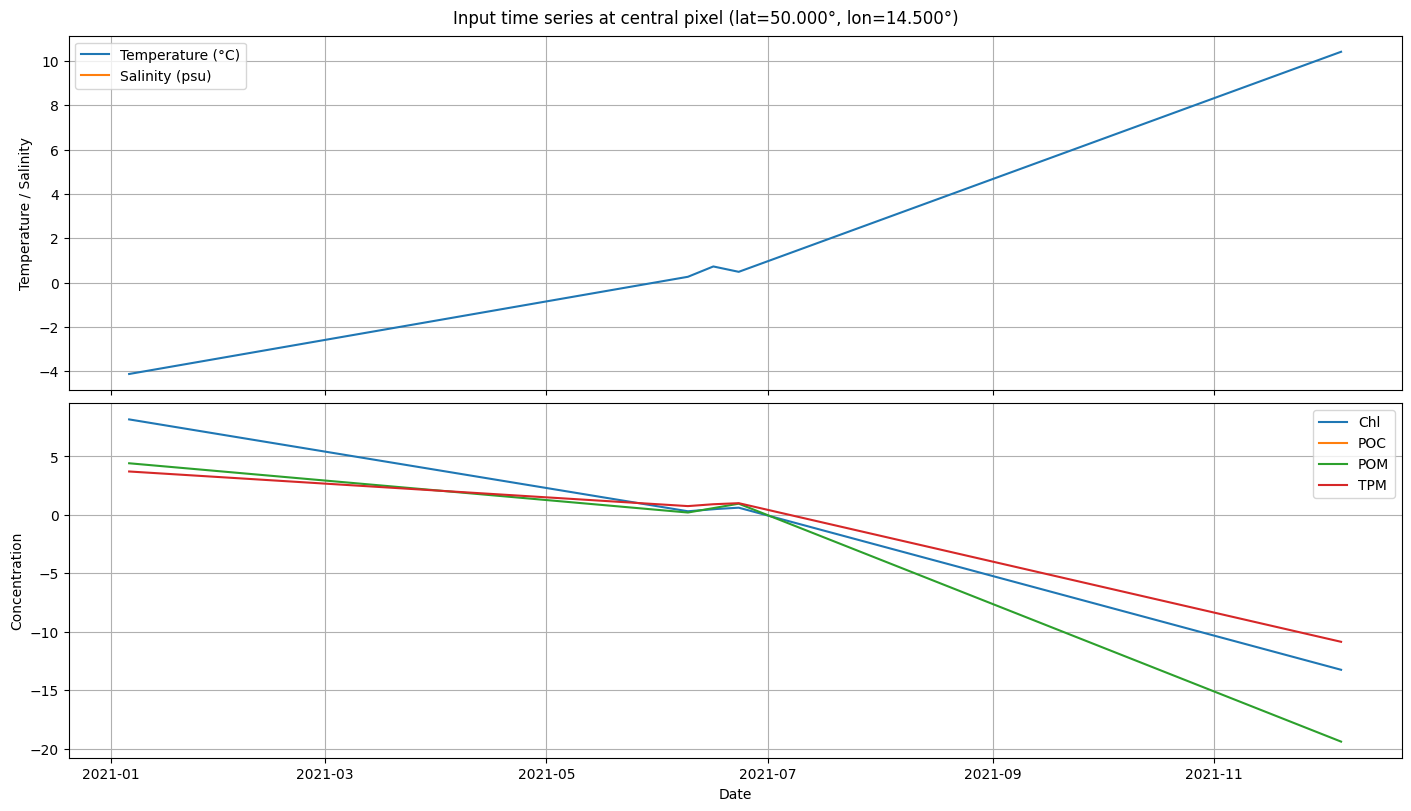

Saved: qc_input_central_point_timeseries.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Input data QC visualisation
#
# WHAT IT SHOWS:
#   Panel 1 (top row):  Spatial time-mean maps — each box shows the average
#                        value of a variable across the whole time period.
#   Panel 2 (bottom):   Time series at the central pixel of the grid.
#
# WHY BOTHER?
#   If the inputs look wrong here, the model output will definitely be wrong.
#   This is your last chance to catch bad data before a long compute run.
# ─────────────────────────────────────────────────────────────────────────────

if ds_daily is None or len(ds_daily.coords.get('time', [])) == 0:
    print('ds_daily is empty or has no time dimension. Skipping QC plots.')
else:
    # ── Spatial maps ──────────────────────────────────────────────────────────
    vars_to_map = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    for ax, var in zip(axes, vars_to_map):
        if var in ds_daily:
            try:
                da_mean = ds_daily[var].mean(dim='time')
                da_mean.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'shrink': 0.8})
                ax.set_title(f'{var} — time mean')
                ax.set_xlabel('Longitude')
                ax.set_ylabel('Latitude')
            except Exception as e:
                ax.text(0.5, 0.5, f'Plot failed:\n{e}', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, f'{var} not found', ha='center', va='center')

    plt.suptitle('Input data — time-mean spatial maps', fontsize=16)
    plt.savefig('qc_input_time_mean_maps.png', dpi=150)
    plt.show()
    print('Saved: qc_input_time_mean_maps.png')

    # ── Time series at central pixel ──────────────────────────────────────────
    lat0   = float(ds_daily.latitude.mean().values)
    lon0   = float(ds_daily.longitude.mean().values)
    point  = ds_daily.sel(latitude=lat0, longitude=lon0, method='nearest')

    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)

    if 'temperature' in point and 'salinity' in point:
        axs[0].plot(point['time'].values, point['temperature'].values, label='Temperature (°C)')
        axs[0].plot(point['time'].values, point['salinity'].values,    label='Salinity (psu)')
        axs[0].set_ylabel('Temperature / Salinity')
        axs[0].legend(); axs[0].grid(True)

    food_vars = [v for v in ['Chl', 'POC', 'POM', 'TPM'] if v in point]
    for v in food_vars:
        axs[1].plot(point['time'].values, point[v].values, label=v)
    axs[1].set_ylabel('Concentration'); axs[1].legend(); axs[1].grid(True)

    plt.xlabel('Date')
    plt.suptitle(f'Input time series at central pixel (lat={lat0:.3f}°, lon={lon0:.3f}°)')
    plt.savefig('qc_input_central_point_timeseries.png', dpi=150)
    plt.show()
    print('Saved: qc_input_central_point_timeseries.png')


## Step 8 — Geographic Subset (Bounding Box)

If you only want to run the model over a specific region (e.g. the Norwegian shelf)
use this function to clip the dataset to a bounding box before the heavy computation.
This dramatically reduces run time.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Bounding-box subsetting helper
#
# FUNCTION: subset_ds(ds, bbox)
#   Crops a dataset to a rectangle on the Earth's surface.
#
# PARAMETERS:
#   ds   – xarray Dataset with 'latitude' and 'longitude' coordinates.
#   bbox – tuple (min_lon, min_lat, max_lon, max_lat)
#           Example: (7.91, 53.04, 31.03, 69.36)  ← North Sea / Norwegian coast
#           Use http://bboxfinder.com to draw and copy bbox coordinates.
#
# HOW IT WORKS:
#   xarray's .sel(coord=slice(start, end)) selects all values between start and end
#   along that coordinate axis — equivalent to a WHERE clause in SQL.
# ─────────────────────────────────────────────────────────────────────────────

def subset_ds(ds: xr.Dataset, bbox: tuple) -> xr.Dataset:
    """
    Subset an xarray Dataset to a geographic bounding box.

    Parameters
    ----------
    ds   : xr.Dataset  with 'latitude' and 'longitude' coordinates.
    bbox : tuple       (min_lon, min_lat, max_lon, max_lat)

    Returns
    -------
    xr.Dataset  – spatially clipped copy of the input.
    """
    min_lon, min_lat, max_lon, max_lat = bbox
    return ds.sel(
        latitude  = slice(min_lat, max_lat),
        longitude = slice(min_lon, max_lon)
    )


# ── Apply the subset ──────────────────────────────────────────────────────────
# Norwegian shelf / North Sea study area.
# Change these values to match your region of interest.
# (min_lon, min_lat, max_lon, max_lat)
# bbox = (7.910156, 53.041213, 31.025391, 69.364831)
bbox = (-17.929688,63.233627,18.281250,71.216075)

ds_daily = subset_ds(ds_daily, bbox)

print(f'Dataset clipped to bbox {bbox}')
print(f'Grid after subset: {dict(ds_daily.dims)}')
ds_daily


Dataset clipped to bbox (-17.929688, 63.233627, 18.28125, 71.216075)
Grid after subset: {'time': 335, 'latitude': 27, 'longitude': 125}


<xarray.Dataset> Size: 50MB
Dimensions:      (time: 335, latitude: 27, longitude: 125)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-06 2021-01-07 ... 2021-12-06
  * latitude     (latitude) float32 108B 63.38 63.62 63.88 ... 69.38 69.62 69.88
  * longitude    (longitude) float32 500B -12.88 -12.62 -12.38 ... 17.88 18.12
    depth        float32 4B 0.0
Data variables:
    temperature  (time, latitude, longitude) float64 9MB dask.array<chunksize=(84, 27, 125), meta=np.ndarray>
    salinity     (time, latitude, longitude) float64 9MB dask.array<chunksize=(42, 27, 125), meta=np.ndarray>
    Chl          (time, latitude, longitude) float64 9MB dask.array<chunksize=(84, 27, 125), meta=np.ndarray>
    POC          (time, latitude, longitude) float32 5MB dask.array<chunksize=(84, 27, 125), meta=np.ndarray>
    POM          (time, latitude, longitude) float64 9MB dask.array<chunksize=(84, 27, 125), meta=np.ndarray>
    TPM          (time, latitude, longitude) float64 9MB dask.array<chunksize=(84, 27, 125), meta=np.ndarray>

## Step 9 — Rechunk for Optimal Parallel Performance

After merging and interpolating, Dask's internal chunk structure can become
fragmented (many tiny chunks).  This cell re-slices the data into clean tiles
so that each Dask task operates on a well-sized block of data.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Rechunk the merged dataset
#
# WHY RECHUNK?
#   After merging six variables and interpolating them onto the same grid,
#   Dask may have created thousands of tiny chunks (one per original file chunk
#   per variable).  Tiny chunks have high overhead — Dask spends more time
#   scheduling tasks than doing actual computation.
#
# THE RULE:
#   Keep `time: -1` (the whole time series per pixel must stay together because
#   the model integrates forward through time step-by-step — it cannot process
#   half a time series).
#   Spatial chunks (lat, lon) control how many pixels are processed per task.
#
# TUNING TIP:
#   If you have more RAM, increase lat/lon chunk sizes.
#   If you run out of memory, reduce them.
# ─────────────────────────────────────────────────────────────────────────────

print('Rechunking dataset for optimal Dask performance...')
ds_daily = ds_daily.chunk({
    'time':      -1,   # Keep full time series intact per pixel
    'latitude':  80,   # Process 80 latitude rows per Dask task
    'longitude': 110   # Process 110 longitude columns per Dask task
})
print('✅ Rechunked.')
print('Chunk structure:', ds_daily.chunks)


Rechunking dataset for optimal Dask performance...
✅ Rechunked.
Chunk structure: Frozen({'time': (335,), 'latitude': (27,), 'longitude': (110, 15)})


## Step 10 — ShellSIM Model Wrapper Function

This is the heart of the notebook.  `run_fabm_at_point_full` is the same
time-stepping loop from `ShellSIM_test_script_timeseries.ipynb` (Notebook 1),
re-packaged as a Python function that accepts 1-D numpy arrays and returns
a 2-D numpy array.  This packaging allows `xarray.apply_ufunc` to call it
for every lat/lon pixel automatically.

**Output variables (13 total):**

| Index | Name | Units | Meaning |
|---|---|---|---|
| 0 | soft_tissue_energy | J | Energy stored in soft tissue — key growth indicator |
| 1 | shell_energy | J | Energy invested in shell |
| 2 | aging | days | Physiological age |
| 3–5 | C1, C2, C3 | — | Cohort size classes (individuals) |
| 6–10 | Chl, POC, POM, TPM, O2 | mg/m³, mg/L | Tracked food/env state variables |
| 11 | TFW | g | Total Fresh Weight |
| 12 | SL | cm | Shell Length |


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Model constants, output naming, and the core FABM wrapper function
#
# N_STATES  – the number of state variables FABM tracks internally (11)
# N_DIAGS   – extra diagnostic variables we read from the model (TFW, SL = 2)
# N_OUTPUTS – total outputs per time step per pixel (11 + 2 = 13)
#
# VARIABLE_NAMES – ordered list matching the row indices in the output array.
#   Row 0  = soft_tissue_energy
#   Row 11 = TFW  (Total Fresh Weight, diagnostic)
#   Row 12 = SL   (Shell Length, diagnostic)
#
# LOG FILE:
#   pyfabm prints a lot of initialisation chatter.  We redirect it to a
#   timestamped log file so the notebook stays readable.
# ─────────────────────────────────────────────────────────────────────────────

timestamp        = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_LOG_FILENAME = f'fabm_run_log_{timestamp}.log'

N_STATES  = 11   # FABM internal state variables
N_DIAGS   = 2    # Extra diagnostic outputs (TFW, SL)
N_OUTPUTS = N_STATES + N_DIAGS  # = 13 total rows in output array

VARIABLE_NAMES = [
    'soft_tissue_energy',  # row 0  – J
    'shell_energy',        # row 1  – J
    'aging',               # row 2  – days
    'C1',                  # row 3  – cohort 1 individuals
    'C2',                  # row 4  – cohort 2 individuals
    'C3',                  # row 5  – cohort 3 individuals
    'Chl',                 # row 6  – mg/m³
    'POC',                 # row 7  – mg/m³
    'POM',                 # row 8  – mg/m³
    'TPM',                 # row 9  – mg/m³
    'O2',                  # row 10 – mg/L
    'TFW',                 # row 11 – g  (diagnostic)
    'SL',                  # row 12 – cm (diagnostic)
]


def run_fabm_at_point_full(T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts, log_filename):
    """
    Run ShellSIM (FABM) for ONE spatial pixel over the full time horizon.

    This is the single-point function from Notebook 1 wrapped so it can be
    called by xr.apply_ufunc in a vectorised, parallel fashion.

    Parameters
    ----------
    T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts : 1-D numpy arrays, length=time_horizon_len
        Daily time series of the six input variables at a single lat/lon point.
    log_filename : str
        Path to the log file where FABM's initialisation output is written.

    Returns
    -------
    outputs : 2-D numpy array, shape (N_OUTPUTS=13, time_horizon_len)
        Each row is one output variable's time series.
        Returns an array of NaN if inputs are invalid or the model crashes.
    """
    # ── Guard: reject pixels with NaN or non-finite input data ───────────────
    # Land pixels, coastal boundaries, and edge-of-dataset regions often contain
    # NaN values. We skip them rather than letting FABM crash.
    all_inputs = [T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts]
    if any(np.any(np.isnan(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)
    if not all(np.all(np.isfinite(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)

    try:
        # ── Redirect FABM's noisy stdout to a log file ────────────────────────
        # pyfabm prints model-configuration messages every time it initialises.
        # Redirecting keeps notebook output clean. The log can be inspected later.
        with open(log_filename, 'a') as f_log, redirect_stdout(f_log):

            # ── Initialise the FABM model for this pixel ──────────────────────
            # A fresh model instance is created for EVERY pixel because FABM is
            # stateful — carrying state between pixels would corrupt results.
            model = pyfabm.Model('/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/fabm.yaml')

            # ── Set static (time-invariant) forcing values ────────────────────
            model.cell_thickness = 1.0   # 1 m water column depth assumption
            model.dependencies['seeding_rate'].value  = 0.0  # no seeding
            model.dependencies['harvest_ratio'].value = 0.0  # no harvesting
            model.dependencies['current_speed'].value = 1.0  # 1 m/s default
            model.dependencies['air_exposure'].value  = 0.0  # fully submerged
            model.dependencies['number_of_days_since_start_of_the_year'].value = 0.0

            # ── Set initial conditions (Day 0 values) ─────────────────────────
            # Before calling model.start() we must provide at least one value
            # for the time-varying inputs.
            model.dependencies['temperature'].value      = float(T_ts[0])
            model.dependencies['practical_salinity'].value = float(S_ts[0])
            model.findStateVariable('Chl1/Chl').value    = float(Chl_ts[0])
            model.findStateVariable('POC1/POC').value    = float(POC_ts[0])
            model.findStateVariable('POM1/POM').value    = float(POM_ts[0])
            model.findStateVariable('TPM1/TPM').value    = float(TPM_ts[0])

            if not model.start():
                raise RuntimeError('FABM model failed to start internally.')

        # ── Output array: rows = variables, columns = time steps ──────────────
        outputs = np.zeros((N_OUTPUTS, time_horizon_len))

        # ── Daily forward-Euler integration loop ─────────────────────────────
        # Forward Euler: new_state = old_state + rate_of_change × dt
        # dt = 86400 seconds = 1 day
        # This is the same loop as in Notebook 1 — the model steps day by day.
        for nd in range(time_horizon_len):

            # Update forcing for this day
            model.dependencies['temperature'].value        = float(T_ts[nd])
            model.dependencies['practical_salinity'].value = float(S_ts[nd])
            model.findStateVariable('Chl1/Chl').value      = float(Chl_ts[nd])
            model.findStateVariable('POC1/POC').value      = float(POC_ts[nd])
            model.findStateVariable('POM1/POM').value      = float(POM_ts[nd])
            model.findStateVariable('TPM1/TPM').value      = float(TPM_ts[nd])

            # Ask FABM: at these conditions, what are the rates of change?
            state_rates = model.getRates()

            # Apply rates over one day (86400 seconds)
            model.state[:] += state_rates * 86400.0

            # Record state variables (rows 0–10)
            outputs[:N_STATES, nd] = model.state[:]

            # Record diagnostic variables (rows 11–12)
            outputs[N_STATES,     nd] = model.diagnostic_variables['Oyster/TFW'].value
            outputs[N_STATES + 1, nd] = model.diagnostic_variables['Oyster/Shell_Length'].value

        return outputs  # shape (13, time_horizon_len)

    except RuntimeError as e:
        warnings.warn(f'FABM model failed to start: {pyfabm.getError()}')
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)
    except Exception as e:
        warnings.warn(f'FABM error at pixel: {str(e)}')
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)


print('ShellSIM wrapper function defined.')
print(f'Output variables ({N_OUTPUTS} total): {VARIABLE_NAMES}')


ShellSIM wrapper function defined.
Output variables (13 total): ['soft_tissue_energy', 'shell_energy', 'aging', 'C1', 'C2', 'C3', 'Chl', 'POC', 'POM', 'TPM', 'O2', 'TFW', 'SL']


---
# METHOD 1 — Full-Grid Parallel Computation (Dask apply_ufunc)

## What this method does

Think of this like handing a teacher a stack of answer sheets and asking them to
mark all of them at once using a team of markers who each grab a sheet and work in
parallel.  Dask is the teacher; the pixels are the answer sheets; `apply_ufunc` hands
them out.

**Technically:** `xr.apply_ufunc` maps `run_fabm_at_point_full` over every
(lat, lon) pixel in the grid simultaneously using Dask's thread scheduler.

**When to use Method 1:**
- You have enough RAM to hold the full output in memory before writing.
- You want the fastest possible wall-clock time.
- Your grid is moderately sized (≤ ~500 × 500 pixels).

**Output:** a single NetCDF file containing all 13 variables.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: METHOD 1 — Build the Dask task graph with apply_ufunc
#
# HOW apply_ufunc WORKS (simplified):
#   Normal xarray operations work element-by-element or along named dimensions.
#   apply_ufunc is the escape hatch for custom functions that consume an entire
#   1-D array (like our time-loop).
#
#   input_core_dims=[['time']] * 6
#       → for each of the 6 input arrays, the 'time' axis is the one our
#         function will consume.  apply_ufunc will loop over all other
#         dimensions (lat, lon) and pass a 1-D time array to the function.
#
#   output_core_dims=[['state', 'time']]
#       → the function returns a 2-D array.  apply_ufunc needs to know
#         the names of those two axes so it can rebuild the xarray structure.
#
#   dask='parallelized'  → tells xarray to pass Dask arrays through unchanged;
#                          Dask will run the function in parallel across chunks.
#
#   vectorize=True       → wraps the function in np.vectorize so apply_ufunc
#                          can call it separately for each (lat, lon) pixel.
#
# NOTE: Nothing is computed here yet.  This cell only builds the task graph
#       (a recipe for what to compute).  Actual computation happens in the
#       next cell when .to_netcdf() triggers Dask.
# ─────────────────────────────────────────────────────────────────────────────

print('Building parallel task graph with apply_ufunc ...')

result_full = xr.apply_ufunc(
    run_fabm_at_point_full,   # the function to call for each pixel

    # Six input DataArrays — each will be sliced along 'time' per pixel
    ds_daily['temperature'],
    ds_daily['salinity'],
    ds_daily['Chl'],
    ds_daily['POC'],
    ds_daily['POM'],
    ds_daily['TPM'],

    # 'time' is the axis our function consumes (1-D input per pixel)
    input_core_dims=[['time']] * 6,

    # Our function returns (state, time) — declare both new axes
    output_core_dims=[['state', 'time']],

    # 'time' is consumed by the function, not passed through — exclude it from broadcast
    exclude_dims=set(('time',)),

    dask='parallelized',  # let Dask parallelise across spatial chunks
    vectorize=True,       # loop over each (lat, lon) pixel automatically
    output_dtypes=[float],

    # Pass the log file path as a keyword argument to the function
    kwargs={'log_filename': RUN_LOG_FILENAME},

    # Tell Dask the sizes of the new dimensions it cannot infer from the input
    dask_gufunc_kwargs={
        'allow_rechunk': True,
        'output_sizes': {'state': N_OUTPUTS, 'time': time_horizon_len}
    }
)

# ── Attach coordinate labels back onto the output ─────────────────────────────
# apply_ufunc strips coordinate information; re-attach time dates and variable names.
result_full = result_full.assign_coords(time=time_horizon)
result_full = result_full.assign_coords(state=VARIABLE_NAMES)

# ── Convert the 'state' dimension into separate named variables ───────────────
# to_dataset(dim='state') turns each state name into its own DataArray
# (e.g. result_dataset['TFW'] gives the TFW map directly).
result_dataset = result_full.to_dataset(dim='state')

# ── Attach human-readable metadata (units and long names) ────────────────────
# These attributes appear in the NetCDF file and in any xarray print/repr.
attrs_map = {
    'soft_tissue_energy': ('J',     'Oyster Dry Soft Tissue Energy'),
    'shell_energy':       ('J',     'Oyster Shell Energy'),
    'aging':              ('days',  'Physiological Age'),
    'C1':                 ('',      'Cohort Size Class 1 (individuals)'),
    'C2':                 ('',      'Cohort Size Class 2 (individuals)'),
    'C3':                 ('',      'Cohort Size Class 3 (individuals)'),
    'Chl':                ('mg/m3', 'Chlorophyll State Variable'),
    'POC':                ('mg/m3', 'Particulate Organic Carbon State'),
    'POM':                ('mg/m3', 'Particulate Organic Matter State'),
    'TPM':                ('mg/m3', 'Total Particulate Matter State'),
    'O2':                 ('mg/L',  'Dissolved Oxygen State'),
    'TFW':                ('g',     'Total Fresh Weight'),
    'SL':                 ('cm',    'Shell Length'),
}
for var, (units, long_name) in attrs_map.items():
    if var in result_dataset:
        result_dataset[var].attrs = {'units': units, 'long_name': long_name}

print('\n✅ Task graph built — no computation yet.')
print(f'   Output dataset will have {N_OUTPUTS} variables × {time_horizon_len} time steps.')
print(result_dataset)


Building parallel task graph with apply_ufunc ...

✅ Task graph built — no computation yet.
   Output dataset will have 13 variables × 335 time steps.
<xarray.Dataset> Size: 118MB
Dimensions:             (latitude: 27, longitude: 125, time: 335)
Coordinates:
  * latitude            (latitude) float32 108B 63.38 63.62 ... 69.62 69.88
  * longitude           (longitude) float32 500B -12.88 -12.62 ... 17.88 18.12
  * time                (time) datetime64[ns] 3kB 2021-01-06 ... 2021-12-06
    depth               float32 4B 0.0
Data variables: (12/13)
    soft_tissue_energy  (latitude, longitude, time) float64 9MB dask.array<chunksize=(27, 110, 335), meta=np.ndarray>
    shell_energy        (latitude, longitude, time) float64 9MB dask.array<chunksize=(27, 110, 335), meta=np.ndarray>
    aging               (latitude, longitude, time) float64 9MB dask.array<chunksize=(27, 110, 335), meta=np.ndarray>
    C1                  (latitude, longitude, time) float64 9MB dask.array<chunksize=(27, 110

### Method 1 — Compute and Save

This cell **triggers the actual computation**.  Dask will now execute all the
parallel tasks, feeding the model for every pixel, and write the results
directly to a NetCDF file.  The progress bar shows how many tasks are complete.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: METHOD 1 — Execute parallel computation and save to NetCDF
#
# .to_netcdf(compute=True) does two things atomically:
#   1. Triggers Dask to run all the pixel-level FABM computations in parallel.
#   2. Streams the results directly to disk as they complete, without holding
#      the entire array in RAM.
#
# ProgressBar() prints a live progress indicator so you know the job is running.
#
# EXPECTED TIMING (rough guide, depends on grid size and CPU count):
#   12-day run, ~1000 ocean pixels : ~30 seconds
#   12-day run, full North Sea grid : ~5–15 minutes
#   Annual run, full grid           : ~1–3 hours
#
# OUTPUT FILE: direct_gridded_oyster_output_ALL_STATES.nc
#   3-D dataset: latitude × longitude × time, with 13 variables.
# ─────────────────────────────────────────────────────────────────────────────

output_file_method1 = 'direct_gridded_oyster_output_ALL_STATES.nc'

print(f'▶ Starting Dask computation — writing to {output_file_method1}')
print('  (The progress bar below tracks completed Dask tasks)')

with ProgressBar():
    result_dataset.to_netcdf(output_file_method1, compute=True)

print(f'\n✅ METHOD 1 COMPLETE — Results saved to: {output_file_method1}')


▶ Starting Dask computation — writing to direct_gridded_oyster_output_ALL_STATES.nc
  (The progress bar below tracks completed Dask tasks)
[#####################################   ] | 94% Completed | 1.63 s ms

Exception ignored on calling ctypes callback function: <function log_callback at 0x730cc0fb9bc0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/pyfabm/__init__.py", line 462, in log_callback
    log(msg.decode("ascii"))
  File "/opt/conda/lib/python3.11/site-packages/pyfabm/__init__.py", line 469, in log
    print(msg)
ValueError: I/O operation on closed file.


[#####################################   ] | 94% Completed | 1.74 s

Exception ignored on calling ctypes callback function: <function log_callback at 0x730cc0fb9bc0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/pyfabm/__init__.py", line 462, in log_callback
    log(msg.decode("ascii"))
  File "/opt/conda/lib/python3.11/site-packages/pyfabm/__init__.py", line 469, in log
    print(msg)
ValueError: I/O operation on closed file.
Exception ignored on calling ctypes callback function: <function log_callback at 0x730cc0fb9bc0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/pyfabm/__init__.py", line 462, in log_callback
    log(msg.decode("ascii"))
  File "/opt/conda/lib/python3.11/site-packages/pyfabm/__init__.py", line 469, in log
    print(msg)
ValueError: I/O operation on closed file.
Exception ignored on calling ctypes callback function: <function log_callback at 0x730cc0fb9bc0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/pyfabm/__init__.py", l

[########################################] | 100% Completed | 37.27 s


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Optional memory cleanup after Method 1
#
# After saving to NetCDF, the large Dask arrays in result_dataset are no longer
# needed in memory.  Calling del + gc.collect() frees RAM before proceeding
# to Method 2 or the visualisation cells.
#
# Uncomment the lines below if you are running both methods back-to-back and
# need to reclaim memory between them.
# ─────────────────────────────────────────────────────────────────────────────

# del ds_poc, ds_sal, ds_temp, ds_chl, ds_pom, ds_tpm
# del result_full, result_dataset
# gc.collect()
# print('Memory freed.')
print('(Memory cleanup cell — uncomment above lines if needed)')


Exception in thread IPythonHistorySavingThread:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/IPython/core/history.py", line 844, in writeout_cache
    self._writeout_input_cache(conn)
  File "/opt/conda/lib/python3.11/site-packages/IPython/core/history.py", line 827, in _writeout_input_cache
    conn.execute("INSERT INTO history VALUES (?, ?, ?, ?)",
sqlite3.IntegrityError: UNIQUE constraint failed: history.session, history.line

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/IPython/core/history.py", line 899, in run
    self.history_manager.writeout_cache(self.db)
  File "/opt/conda/lib/python3.11/site-packages/decorator.py", line 232, in fun
    return caller(func, *(extras + args), **kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/IPython/core/history.py", line 60, in only_when_enabled
    

---
# METHOD 2 — Memory-Safe Batched Computation

## What this method does

Instead of queuing every pixel at once and writing one file at the end,
this method processes the grid in **spatial tiles** one at a time.
Each tile is computed, written to the output file, then discarded from memory
before the next tile starts.

Imagine assembling a large jigsaw puzzle but only ever having 10 pieces on
the table at once — you finish each section before fetching the next batch.

**When to use Method 2:**
- Your server / laptop has limited RAM.
- The full grid is very large (hundreds of thousands of pixels).
- You want to resume from a specific tile if the run fails midway.

**Trade-off:** Slightly slower than Method 1 because there is overhead from
writing each batch separately, but RAM usage stays nearly constant.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: METHOD 2 — Batched spatial processing with incremental NetCDF writing
#
# HOW BATCHING WORKS:
#   1. Read the Dask chunk structure from ds_daily to find the natural tile
#      boundaries (lat_chunks, lon_chunks).
#   2. Loop over every lat-chunk × lon-chunk combination.
#   3. For each tile:
#      a. Slice ds_daily to just that tile's pixels (ds_subset).
#      b. Build an apply_ufunc task graph for the tile.
#      c. Compute the tile (triggers FABM for those pixels).
#      d. Append to the NetCDF output file.
#      e. Python garbage-collects the tile's data — RAM is freed.
#
# FILE WRITING STRATEGY:
#   mode='w'  → first tile: create the file fresh.
#   mode='a'  → all subsequent tiles: append to the existing file.
#   This incremental approach means the output file grows as tiles finish;
#   you can read partial results before the full run completes.
#
# NOTE ON N_OUTPUTS vs N_STATES IN METHOD 2:
#   The STATE_NAMES list here has 11 entries (N_STATES only) to demonstrate
#   a minimal output.  To match Method 1's 13-variable output, change
#   N_STATES → N_OUTPUTS and STATE_NAMES → VARIABLE_NAMES.
# ─────────────────────────────────────────────────────────────────────────────

time_horizon_len   = ds_daily.time.size
output_file_method2 = 'gridded_oyster_output_ALL_STATES_batched.nc'

# State variable names for this method (11 state vars; extend to VARIABLE_NAMES for all 13)
STATE_NAMES = [
    'soft_tissue_energy', 'shell_energy', 'aging',
    'C1', 'C2', 'C3',
    'Chl_state', 'POC_state', 'POM_state', 'TPM_state', 'O2'
]

# ── Derive spatial tile boundaries from Dask chunk sizes ─────────────────────
# lat_chunks / lon_chunks are tuples like (80, 80, 40) — the number of
# lat/lon indices in each chunk.  cumsum gives us the start/end index of
# each tile.
try:
    lat_chunks = ds_daily.chunks['latitude']
    lon_chunks = ds_daily.chunks['longitude']
except KeyError:
    raise RuntimeError('ds_daily must be a Dask-backed dataset with defined latitude/longitude chunks. '
                       'Did you run the rechunking cell?')

lat_indices = np.cumsum([0] + list(lat_chunks))  # e.g. [0, 80, 160, 200]
lon_indices = np.cumsum([0] + list(lon_chunks))  # e.g. [0, 110, 220, ...]

total_tiles = len(lat_chunks) * len(lon_chunks)
tile_count  = 0

print(f'Starting batched computation → {output_file_method2}')
print(f'Grid tiles: {len(lat_chunks)} lat × {len(lon_chunks)} lon = {total_tiles} total tiles\n')

# ── Outer loop: latitude tiles ────────────────────────────────────────────────
for i, lat_chunk in enumerate(lat_chunks):
    lat_start = lat_indices[i]
    lat_end   = lat_indices[i + 1]

    # ── Inner loop: longitude tiles ───────────────────────────────────────────
    for j, lon_chunk in enumerate(lon_chunks):
        lon_start = lon_indices[j]
        lon_end   = lon_indices[j + 1]

        tile_count += 1
        print(f'  Tile {tile_count}/{total_tiles} — lat[{lat_start}:{lat_end}] lon[{lon_start}:{lon_end}]')

        # ── Slice the input data to just this tile ────────────────────────────
        ds_subset = ds_daily.isel(
            latitude  = slice(lat_start, lat_end),
            longitude = slice(lon_start, lon_end)
        )

        # ── Build tile-level apply_ufunc task graph ───────────────────────────
        # Identical to Method 1 but scoped to the tile's pixel count.
        result_batch = xr.apply_ufunc(
            run_fabm_at_point_full,
            ds_subset['temperature'],
            ds_subset['salinity'],
            ds_subset['Chl'],
            ds_subset['POC'],
            ds_subset['POM'],
            ds_subset['TPM'],
            input_core_dims=[['time']] * 6,
            output_core_dims=[['state', 'time']],
            exclude_dims=set(('time',)),
            dask='parallelized',
            vectorize=True,
            output_dtypes=[float],
            kwargs={'log_filename': RUN_LOG_FILENAME},
            dask_gufunc_kwargs={
                'allow_rechunk': True,
                'output_sizes': {'state': N_STATES, 'time': time_horizon_len}
            }
        )

        # ── Re-attach coordinates ──────────────────────────────────────────────
        result_batch = result_batch.assign_coords(time=ds_subset.time)
        result_batch = result_batch.assign_coords(state=STATE_NAMES)
        result_batch_ds = result_batch.to_dataset(dim='state')

        # Attach units metadata
        result_batch_ds['soft_tissue_energy'].attrs = {'units': 'J',  'long_name': 'Oyster Soft Tissue Energy'}
        result_batch_ds['shell_energy'].attrs       = {'units': 'J',  'long_name': 'Oyster Shell Energy'}

        # ── Compute this tile and append to file ──────────────────────────────
        # mode='w' creates a new file on the first tile.
        # mode='a' appends to the existing file on subsequent tiles.
        # Using NETCDF4 format allows appending; NETCDF3 does not.
        write_mode = 'w' if (i == 0 and j == 0) else 'a'

        with ProgressBar():
            result_batch_ds.to_netcdf(
                output_file_method2,
                mode=write_mode,
                format='NETCDF4',
                compute=True
            )

        # ── Free tile memory before next iteration ────────────────────────────
        del result_batch, result_batch_ds, ds_subset
        gc.collect()

print(f'\n✅ METHOD 2 COMPLETE — All {total_tiles} tiles saved to: {output_file_method2}')


---
# Part 3 — Insight Visualisation

The cells below let users explore the model output in two ways:

| Interaction | What you get |
|---|---|
| **Click a point** (lat / lon) | Full enriched time-series dashboard for that pixel |
| **Draw a bounding box** | Spatial maps, area statistics, histograms, and growth-potential summary |

Both sections read from the saved NetCDF output so they can be run
independently of the computation cells above.


## Step 11 — Load Saved Model Output for Visualisation

Load the NetCDF file produced by Method 1 (or Method 2 — they share the same structure).
Adjust `output_file_to_visualise` if you want to inspect a different file.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Load model output for all downstream visualisation
#
# We re-open the saved NetCDF rather than using the in-memory result_dataset
# because:
#   a) The file may have been computed in a previous session.
#   b) Opening from disk guarantees clean coordinates and attributes.
#   c) lazy=True (default with chunks) means only the data you select is
#      actually read into RAM — full-grid loads stay fast.
# ─────────────────────────────────────────────────────────────────────────────

output_file_to_visualise = 'direct_gridded_oyster_output_ALL_STATES.nc'
# Uncomment the line below to use the batched Method 2 output instead:
# output_file_to_visualise = 'gridded_oyster_output_ALL_STATES_batched.nc'

ds_out = xr.open_dataset(output_file_to_visualise, chunks={'latitude': 80, 'longitude': 110})

print(f'Loaded: {output_file_to_visualise}')
print('Variables:', list(ds_out.data_vars))
print('Dimensions:', dict(ds_out.dims))
ds_out


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Find a valid (non-NaN) pixel automatically
#
# WHY NEEDED?
#   Over land or near missing-data edges, the model returns NaN.
#   If you hard-code a lat/lon that falls on land the plots will be empty.
#   This cell scans the TFW variable and finds the first pixel with real data.
#
# WHAT IT SETS:
#   `valid_lat`, `valid_lon` – a guaranteed valid starting point for plotting.
#   These are printed so you can copy them into the point-insight cell below.
# ─────────────────────────────────────────────────────────────────────────────

print('Scanning output for first valid (non-NaN) data pixel...')

valid_mask    = ~ds_out['TFW'].isnull()
valid_indices = np.where(valid_mask.values)

if len(valid_indices[0]) == 0:
    print('❌ ERROR: The entire dataset is NaN.  Check your input data quality.')
    valid_lat, valid_lon = None, None
else:
    first_lat_idx = valid_indices[0][0]
    first_lon_idx = valid_indices[1][0]
    valid_lat = float(ds_out.latitude.isel(latitude=first_lat_idx).values)
    valid_lon = float(ds_out.longitude.isel(longitude=first_lon_idx).values)
    print(f'\n✅ First valid pixel found:')
    print(f'   Latitude  : {valid_lat}')
    print(f'   Longitude : {valid_lon}')
    print(f'\nUse these in the point-insight cell below, or pick any blue pixel from the coverage map.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Data coverage map
#
# This map shows WHERE the model produced valid results.
#   Blue  = valid data  (ocean pixels with complete input forcing)
#   White = NaN         (land, ice, or pixels with missing input data)
#
# HOW TO READ:
#   Pick a blue pixel's coordinates for the point-insight cell below.
#   Draw a bounding box over a group of blue pixels for the area-insight cell.
# ─────────────────────────────────────────────────────────────────────────────

data_coverage = ~ds_out['TFW'].isnull().all(dim='time')

fig, ax = plt.subplots(figsize=(10, 7))
data_coverage.plot(
    ax=ax,
    cmap='Blues',
    cbar_kwargs={'label': 'Has valid data (1=yes, 0=NaN)'}
)
if valid_lat is not None:
    ax.scatter(valid_lon, valid_lat, color='red', s=60, zorder=5, label=f'First valid pixel ({valid_lat:.2f}, {valid_lon:.2f})')
    ax.legend()
ax.set_title('Model Output Coverage Map\n(blue = valid ocean data; white = land/no data)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('coverage_map.png', dpi=150)
plt.show()
print('Saved: coverage_map.png')


---
## Single-Point Insight Dashboard

Set `plot_lat` and `plot_lon` to any ocean location within your grid.
The cell below generates a **7-panel dashboard** for that single pixel showing:

1. Soft Tissue Energy trajectory over time
2. Shell Energy trajectory
3. Total Fresh Weight (commercial harvest indicator)
4. Shell Length (size indicator)
5. Driving environmental conditions (Temperature + Salinity)
6. Food availability (Chl, POC, POM, TPM)
7. A printed **summary statistics card** with growth metrics

Copy `valid_lat` / `valid_lon` from the cell above, or choose any coordinate
inside the blue area of the coverage map.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: ENRICHED SINGLE-POINT DASHBOARD
#
# USER INPUTS — change these two values to inspect any grid point:
plot_lat = 67.625   # ← latitude of the point you want to inspect
plot_lon = 8.125    # ← longitude of the point you want to inspect
# TIP: use valid_lat / valid_lon from the cell above if unsure where to start.
# ─────────────────────────────────────────────────────────────────────────────

print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  SINGLE-POINT INSIGHT REPORT')
print(f'  Location : Lat {plot_lat}°  Lon {plot_lon}°')
print(f'  Period   : {str(ds_out.time.values[0])[:10]}  →  {str(ds_out.time.values[-1])[:10]}')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n')

try:
    # Select the nearest grid pixel to the requested lat/lon
    pt = ds_out.sel(latitude=plot_lat, longitude=plot_lon, method='nearest').load()
    actual_lat = float(pt.latitude.values)
    actual_lon = float(pt.longitude.values)
    print(f'  Nearest grid pixel: Lat {actual_lat:.3f}°  Lon {actual_lon:.3f}°\n')

    # Check if this pixel has valid data
    if pt['soft_tissue_energy'].isnull().all():
        print('⚠️  WARNING: All values at this point are NaN.')
        print('   The point may be over land or outside the valid data extent.')
        print('   Use the coverage map above to pick a blue (valid) pixel.')
    else:
        # ─── Derived growth metrics ──────────────────────────────────────────
        # We compute a set of summary statistics that tell an end user how
        # well oysters would grow at this location over the simulated period.
        times   = pd.to_datetime(pt.time.values)
        n_days  = len(times)

        ste_ts   = pt['soft_tissue_energy'].values
        shell_ts = pt['shell_energy'].values
        tfw_ts   = pt['TFW'].values
        sl_ts    = pt['SL'].values

        # Growth = final value minus initial value (absolute change over period)
        ste_growth   = ste_ts[-1]   - ste_ts[0]   if not np.isnan(ste_ts[-1])   else np.nan
        shell_growth = shell_ts[-1] - shell_ts[0] if not np.isnan(shell_ts[-1]) else np.nan
        tfw_growth   = tfw_ts[-1]   - tfw_ts[0]   if not np.isnan(tfw_ts[-1])   else np.nan
        sl_growth    = sl_ts[-1]    - sl_ts[0]     if not np.isnan(sl_ts[-1])    else np.nan

        # Daily growth rate = total growth / number of days
        daily_tfw_rate = tfw_growth / n_days if not np.isnan(tfw_growth) else np.nan
        daily_sl_rate  = sl_growth  / n_days if not np.isnan(sl_growth)  else np.nan

        # Peak values
        peak_ste  = np.nanmax(ste_ts)
        peak_sl   = np.nanmax(sl_ts)
        peak_tfw  = np.nanmax(tfw_ts)

        # Day-of-peak
        day_peak_ste = times[np.nanargmax(ste_ts)].strftime('%Y-%m-%d') if not np.all(np.isnan(ste_ts)) else 'N/A'
        day_peak_tfw = times[np.nanargmax(tfw_ts)].strftime('%Y-%m-%d') if not np.all(np.isnan(tfw_ts)) else 'N/A'

        # ─── Print summary card ───────────────────────────────────────────────
        print('  ┌─────────────────────────────────────────────────────┐')
        print('  │  GROWTH SUMMARY STATISTICS                          │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Soft Tissue Energy                                 │')
        print(f'  │    Start : {ste_ts[0]:.2f} J   End : {ste_ts[-1]:.2f} J   Change: {ste_growth:+.2f} J  │')
        print(f'  │    Peak  : {peak_ste:.2f} J  on {day_peak_ste:<20}       │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Total Fresh Weight (TFW)                           │')
        print(f'  │    Start : {tfw_ts[0]:.3f} g   End : {tfw_ts[-1]:.3f} g   Change: {tfw_growth:+.3f} g │')
        print(f'  │    Peak  : {peak_tfw:.3f} g  on {day_peak_tfw:<20}       │')
        print(f'  │    Daily growth rate: {daily_tfw_rate:.4f} g/day               │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Shell Length (SL)                                  │')
        print(f'  │    Start : {sl_ts[0]:.3f} cm  End : {sl_ts[-1]:.3f} cm  Change: {sl_growth:+.4f} cm│')
        print(f'  │    Peak  : {peak_sl:.3f} cm                                │')
        print(f'  │    Daily growth rate: {daily_sl_rate:.5f} cm/day              │')
        print('  └─────────────────────────────────────────────────────┘')

        # ─── 7-panel dashboard figure ─────────────────────────────────────────
        fig = plt.figure(figsize=(18, 22))
        gs  = GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

        # -- Panel 1: Soft Tissue Energy --
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(times, ste_ts, color='steelblue', lw=2)
        ax1.fill_between(times, ste_ts, alpha=0.15, color='steelblue')
        ax1.axhline(ste_ts[0], color='grey', ls='--', lw=1, label=f'Day-1 baseline: {ste_ts[0]:.1f} J')
        ax1.set_title('Soft Tissue Energy (STE)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('STEn [J]'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.4)

        # -- Panel 2: Shell Energy --
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(times, shell_ts, color='saddlebrown', lw=2)
        ax2.fill_between(times, shell_ts, alpha=0.15, color='saddlebrown')
        ax2.set_title('Shell Energy', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Shell Energy [J]'); ax2.grid(True, alpha=0.4)

        # -- Panel 3: Total Fresh Weight --
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(times, tfw_ts, color='forestgreen', lw=2)
        ax3.fill_between(times, tfw_ts, alpha=0.15, color='forestgreen')
        ax3.axhline(tfw_ts[-1], color='red', ls=':', lw=1.5, label=f'Final: {tfw_ts[-1]:.3f} g')
        ax3.set_title('Total Fresh Weight (TFW) — Commercial indicator', fontsize=12, fontweight='bold')
        ax3.set_ylabel('TFW [g]'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.4)

        # -- Panel 4: Shell Length --
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.plot(times, sl_ts, color='crimson', lw=2)
        ax4.fill_between(times, sl_ts, alpha=0.15, color='crimson')
        ax4.axhline(sl_ts[-1], color='red', ls=':', lw=1.5, label=f'Final: {sl_ts[-1]:.3f} cm')
        ax4.set_title('Shell Length (SL)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('SL [cm]'); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.4)

        # -- Panel 5: Growth rates (daily delta) --
        ax5 = fig.add_subplot(gs[2, 0])
        daily_tfw_delta = np.diff(tfw_ts, prepend=tfw_ts[0])
        colors5 = ['forestgreen' if v >= 0 else 'tomato' for v in daily_tfw_delta]
        ax5.bar(times, daily_tfw_delta, color=colors5, width=0.8, alpha=0.8)
        ax5.axhline(0, color='black', lw=0.8)
        ax5.set_title('Daily TFW Growth Rate', fontsize=12, fontweight='bold')
        ax5.set_ylabel('Δ TFW [g/day]'); ax5.grid(True, axis='y', alpha=0.4)

        # -- Panel 6: Environmental drivers (T + S) --
        ax6 = fig.add_subplot(gs[2, 1])
        if 'temperature' in ds_daily and 'salinity' in ds_daily:
            env_pt = ds_daily.sel(latitude=actual_lat, longitude=actual_lon, method='nearest').load()
            ax6.plot(times, env_pt['temperature'].values, color='orangered', lw=2, label='Temp (°C)')
            ax6b = ax6.twinx()
            ax6b.plot(times, env_pt['salinity'].values, color='dodgerblue', lw=2, ls='--', label='Salinity (psu)')
            ax6b.set_ylabel('Salinity [psu]', color='dodgerblue')
        ax6.set_title('Environmental Drivers: Temperature & Salinity', fontsize=12, fontweight='bold')
        ax6.set_ylabel('Temperature [°C]', color='orangered')
        ax6.grid(True, alpha=0.4)
        lines6a, labs6a = ax6.get_legend_handles_labels()
        lines6b, labs6b = ax6b.get_legend_handles_labels()
        ax6.legend(lines6a + lines6b, labs6a + labs6b, fontsize=8)

        # -- Panel 7: Food availability --
        ax7 = fig.add_subplot(gs[3, :])
        food_colors = {'Chl': 'olive', 'POC': 'darkorange', 'POM': 'purple', 'TPM': 'teal'}
        if 'temperature' in ds_daily:
            env_pt2 = ds_daily.sel(latitude=actual_lat, longitude=actual_lon, method='nearest').load()
            for fvar, fcol in food_colors.items():
                if fvar in env_pt2:
                    ax7.plot(times, env_pt2[fvar].values, lw=1.5, label=fvar, color=fcol)
        ax7.set_title('Food Availability Drivers (Chl, POC, POM, TPM)', fontsize=12, fontweight='bold')
        ax7.set_ylabel('Concentration [mg/m³]'); ax7.legend(fontsize=9); ax7.grid(True, alpha=0.4)

        # Shared x-axis formatting
        for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
            ax.tick_params(axis='x', rotation=30)

        fig.suptitle(
            f'ShellSIM — Point Insight Dashboard\nLat {actual_lat:.3f}°  Lon {actual_lon:.3f}°  '
            f'({str(times[0].date())} → {str(times[-1].date())})',
            fontsize=14, fontweight='bold', y=1.01
        )
        plt.savefig(f'point_dashboard_{actual_lat:.2f}_{actual_lon:.2f}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'\nSaved: point_dashboard_{actual_lat:.2f}_{actual_lon:.2f}.png')

except Exception as e:
    print(f'\n❌ ERROR loading data for point ({plot_lat}, {plot_lon}): {e}')
    print("   Make sure 'ds_out' is loaded and the coordinate is within the grid.")


---
## Bounding-Box (Area) Insight Dashboard

Users draw a rectangle on a map, set a start/end date, and want to know:
**"How does oyster growth look across the whole area I selected?"**

This cell produces a **multi-panel area report** containing:

| Panel | What it shows | Why it matters |
|---|---|---|
| Spatial mean maps | Average STE, TFW, SL over time | Identify the best-performing zones |
| Area-mean time series | How the 'average oyster' in the box grew | Overall growth trend for the region |
| Spatial variability map | Std-dev of TFW across pixels | Highlights patchy vs. uniform conditions |
| Growth potential map | Final TFW map | Where harvest yield would be highest |
| Histogram | Distribution of final TFW across pixels | Is growth broadly similar or highly skewed? |
| Summary statistics table | Min/max/mean/percentiles per variable | At-a-glance numbers for the drawn area |

**HOW TO USE:**
1. Set `bbox_user` to your drawn bounding box `(min_lon, min_lat, max_lon, max_lat)`.
2. Optionally narrow the time window with `bbox_time_start` / `bbox_time_end`.
3. Run the cell.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: BOUNDING-BOX AREA INSIGHT DASHBOARD
#
# USER INPUTS — set your drawn bounding box and optional date range:
#
bbox_user       = (8.0, 55.0, 25.0, 68.0)   # (min_lon, min_lat, max_lon, max_lat)
bbox_time_start = None   # e.g. '2021-06-01' or None to use full time range
bbox_time_end   = None   # e.g. '2021-06-12' or None to use full time range
#
# HOW TO GET bbox COORDINATES:
#   1. Go to http://bboxfinder.com
#   2. Draw a rectangle over your area of interest
#   3. Copy the four numbers from the BBOX box
# ─────────────────────────────────────────────────────────────────────────────

min_lon, min_lat, max_lon, max_lat = bbox_user

# ── Clip the output dataset to the drawn bounding box ────────────────────────
ds_bbox = ds_out.sel(
    latitude  = slice(min_lat, max_lat),
    longitude = slice(min_lon, max_lon)
)

# ── Optional: narrow to a specific date range ─────────────────────────────────
if bbox_time_start is not None and bbox_time_end is not None:
    ds_bbox = ds_bbox.sel(time=slice(bbox_time_start, bbox_time_end))

# ── Compute (bring into memory — bbox is small so this is fast) ───────────────
ds_bbox = ds_bbox.compute()

n_lat      = ds_bbox.dims.get('latitude',  ds_bbox.dims.get('lat', 0))
n_lon      = ds_bbox.dims.get('longitude', ds_bbox.dims.get('lon', 0))
n_t        = ds_bbox.dims.get('time', 0)
n_pixels   = n_lat * n_lon
bbox_times = pd.to_datetime(ds_bbox.time.values)

print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  AREA INSIGHT REPORT')
print(f'  Bounding box   : ({min_lon}, {min_lat}) → ({max_lon}, {max_lat})')
print(f'  Grid cells     : {n_lat} lat × {n_lon} lon = {n_pixels} pixels')
print(f'  Time steps     : {n_t}  ({str(bbox_times[0].date())} → {str(bbox_times[-1].date())})')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n')

# ── Compute area-mean time series (average over all pixels in the box) ────────
# This answers: 'how did the average oyster in this region grow over time?'
area_mean = ds_bbox[['soft_tissue_energy', 'shell_energy', 'TFW', 'SL']].mean(
    dim=['latitude', 'longitude'], skipna=True
)
area_std = ds_bbox[['soft_tissue_energy', 'shell_energy', 'TFW', 'SL']].std(
    dim=['latitude', 'longitude'], skipna=True
)

# ── Compute spatial maps (time-mean) ─────────────────────────────────────────
# For each pixel, what was the average value over the whole period?
spatial_mean_ste  = ds_bbox['soft_tissue_energy'].mean(dim='time', skipna=True)
spatial_mean_tfw  = ds_bbox['TFW'].mean(dim='time', skipna=True)
spatial_mean_sl   = ds_bbox['SL'].mean(dim='time', skipna=True)
spatial_std_tfw   = ds_bbox['TFW'].std(dim='time',  skipna=True)  # variability
spatial_final_tfw = ds_bbox['TFW'].isel(time=-1)                  # last day

# ── Summary statistics table ──────────────────────────────────────────────────
# Flatten all pixels and times into a vector for each key variable
def area_stats(da, name, units):
    vals = da.values.flatten()
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return f'{name}: all NaN'
    return (f'  {name:<28} min={vals.min():.3f} {units}  '
            f'mean={vals.mean():.3f} {units}  '
            f'max={vals.max():.3f} {units}  '
            f'p25={np.percentile(vals, 25):.3f}  '
            f'p75={np.percentile(vals, 75):.3f}')

print('  AREA STATISTICS (across all pixels, time-mean values)')
print('  ' + '─' * 80)
print(area_stats(spatial_mean_ste,  'Soft Tissue Energy (STE)', 'J'))
print(area_stats(spatial_mean_tfw,  'Total Fresh Weight (TFW)', 'g'))
print(area_stats(spatial_mean_sl,   'Shell Length (SL)',         'cm'))
print(area_stats(spatial_final_tfw, 'Final TFW (last day)',      'g'))

# Count valid pixels
valid_pixel_count = int((~np.isnan(spatial_final_tfw.values)).sum())
print(f'\n  Valid ocean pixels : {valid_pixel_count} / {n_pixels}  ({100*valid_pixel_count/max(n_pixels,1):.1f}% coverage)')

# ── Growth rates across the area ──────────────────────────────────────────────
tfw_vals = area_mean['TFW'].values
sl_vals  = area_mean['SL'].values
area_tfw_growth = tfw_vals[-1] - tfw_vals[0] if not np.isnan(tfw_vals[-1]) else np.nan
area_sl_growth  = sl_vals[-1]  - sl_vals[0]  if not np.isnan(sl_vals[-1])  else np.nan
print(f'\n  Area-mean TFW change over period : {area_tfw_growth:+.4f} g  ({area_tfw_growth/n_t:.5f} g/day)')
print(f'  Area-mean SL change over period  : {area_sl_growth:+.5f} cm ({area_sl_growth/n_t:.6f} cm/day)')

print('\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

# ═══════════════════════════════════════════════════════════════════════════════
# MULTI-PANEL AREA DASHBOARD FIGURE
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 24))
gs  = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

# Helper: plot a spatial map
def plot_map(ax, da, title, cmap, units, cbar_label=None):
    try:
        lat_dim = 'latitude' if 'latitude' in da.dims else 'lat'
        lon_dim = 'longitude' if 'longitude' in da.dims else 'lon'
        im = ax.pcolormesh(
            da[lon_dim].values, da[lat_dim].values, da.values,
            cmap=cmap, shading='auto'
        )
        plt.colorbar(im, ax=ax, shrink=0.85, label=cbar_label or units)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        # Draw the bbox boundary
        rect = mpatches.Rectangle(
            (min_lon, min_lat), max_lon - min_lon, max_lat - min_lat,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)

# -- ROW 1: Spatial mean maps -------------------------------------------------
plot_map(fig.add_subplot(gs[0, 0]), spatial_mean_ste,  'Time-mean STE [J]',    'Blues',  'J')
plot_map(fig.add_subplot(gs[0, 1]), spatial_mean_tfw,  'Time-mean TFW [g]',    'Greens', 'g')
plot_map(fig.add_subplot(gs[0, 2]), spatial_mean_sl,   'Time-mean Shell Length [cm]', 'Reds', 'cm')

# -- ROW 2: Variability + final harvest potential ----------------------------
plot_map(fig.add_subplot(gs[1, 0]), spatial_std_tfw,   'TFW Spatial Variability (σ) [g]', 'YlOrRd', 'g',
         cbar_label='Std Dev of TFW [g]')
plot_map(fig.add_subplot(gs[1, 1]), spatial_final_tfw, 'Final Day TFW — Harvest Potential [g]', 'plasma', 'g')

# Histogram of final TFW across all valid pixels
ax_hist = fig.add_subplot(gs[1, 2])
final_tfw_flat = spatial_final_tfw.values.flatten()
final_tfw_flat = final_tfw_flat[~np.isnan(final_tfw_flat)]
if len(final_tfw_flat) > 0:
    ax_hist.hist(final_tfw_flat, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax_hist.axvline(np.mean(final_tfw_flat), color='red', lw=2, label=f'Mean: {np.mean(final_tfw_flat):.3f} g')
    ax_hist.axvline(np.percentile(final_tfw_flat, 25), color='orange', lw=1.5, ls='--', label='P25')
    ax_hist.axvline(np.percentile(final_tfw_flat, 75), color='orange', lw=1.5, ls='-.', label='P75')
    ax_hist.set_xlabel('Final TFW [g]'); ax_hist.set_ylabel('Pixel count')
    ax_hist.set_title('Distribution of Final TFW across Area', fontsize=10, fontweight='bold')
    ax_hist.legend(fontsize=8); ax_hist.grid(True, alpha=0.4)

# -- ROW 3: Area-mean time series with uncertainty band ----------------------
ax_ts1 = fig.add_subplot(gs[2, :2])
ax_ts1.plot(bbox_times, area_mean['TFW'].values, color='forestgreen', lw=2, label='Area mean TFW')
ax_ts1.fill_between(
    bbox_times,
    area_mean['TFW'].values - area_std['TFW'].values,
    area_mean['TFW'].values + area_std['TFW'].values,
    alpha=0.2, color='forestgreen', label='±1 std dev'
)
ax_ts1.set_title('Area-mean Total Fresh Weight over time  (shading = pixel-to-pixel variability)',
                 fontsize=10, fontweight='bold')
ax_ts1.set_ylabel('TFW [g]'); ax_ts1.legend(fontsize=9); ax_ts1.grid(True, alpha=0.4)

ax_ts2 = fig.add_subplot(gs[2, 2])
ax_ts2.plot(bbox_times, area_mean['SL'].values, color='crimson', lw=2, label='Area mean SL')
ax_ts2.fill_between(
    bbox_times,
    area_mean['SL'].values - area_std['SL'].values,
    area_mean['SL'].values + area_std['SL'].values,
    alpha=0.2, color='crimson', label='±1 std dev'
)
ax_ts2.set_title('Area-mean Shell Length over time', fontsize=10, fontweight='bold')
ax_ts2.set_ylabel('SL [cm]'); ax_ts2.legend(fontsize=9); ax_ts2.grid(True, alpha=0.4)

# -- ROW 4: STE area-mean time series ----------------------------------------
ax_ste = fig.add_subplot(gs[3, :])
ax_ste.plot(bbox_times, area_mean['soft_tissue_energy'].values, color='steelblue', lw=2, label='Area mean STE')
ax_ste.fill_between(
    bbox_times,
    area_mean['soft_tissue_energy'].values - area_std['soft_tissue_energy'].values,
    area_mean['soft_tissue_energy'].values + area_std['soft_tissue_energy'].values,
    alpha=0.2, color='steelblue', label='±1 std dev'
)
ax_ste.set_title('Area-mean Soft Tissue Energy over time  (shading = pixel-to-pixel variability)',
                 fontsize=10, fontweight='bold')
ax_ste.set_ylabel('STE [J]'); ax_ste.legend(fontsize=9); ax_ste.grid(True, alpha=0.4)

# Shared x-axis formatting
for ax in [ax_ts1, ax_ts2, ax_ste]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=30)

fig.suptitle(
    f'ShellSIM — Area Insight Dashboard\n'
    f'BBox: ({min_lon}, {min_lat}) → ({max_lon}, {max_lat})   '
    f'{str(bbox_times[0].date())} → {str(bbox_times[-1].date())}\n'
    f'({valid_pixel_count} valid pixels  |  area-mean growth TFW {area_tfw_growth:+.4f} g  SL {area_sl_growth:+.5f} cm)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('area_dashboard_bbox.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: area_dashboard_bbox.png')


---
## Appendix — Re-read and Explore a Previously Saved Output File

Use this cell at any time to load a NetCDF output file without re-running
the model.  Handy for continuing analysis in a fresh notebook session.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Load a previously saved output file for standalone exploration
#
# Change output_file_path to point at whatever .nc file you want to inspect.
# ─────────────────────────────────────────────────────────────────────────────

output_file_path = '/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/direct_gridded_oyster_output_ALL_STATES.nc'

if os.path.exists(output_file_path):
    ds_loaded = load_nc_file(output_file_path, 'SL')
    print(ds_loaded)
else:
    print(f'File not found: {output_file_path}')
    print('Run Methods 1 or 2 above to generate the output first.')
